# Burgers Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Burgers equation using the multi-trajectory (Part 1) workflow.

## Governing equations

The one-dimensional viscous Burgers equation is

$$
\partial_t u + u\partial_x u = \nu\partial_{xx} u,
$$

where $u(x,t)$ is the state variable and $\nu$ is the viscosity coefficient.

We use viscosity $\nu$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.burgers import (
    BurgersMultiTrajectoryGLSConfig,
    generate_burgers_dataset,
    run_burgers_multi_trajectory_gls_experiment,
)
from mfsindy.cases.burgers_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]


In [2]:
cfg = BurgersMultiTrajectoryGLSConfig(
    n_runs=25,
    results_dir=str(RESULTS_DIR),
    results_filename="burgers_part1_errors.csv",
)

print(
    f"Running Part 1 Burgers experiment with n_LF={cfg.n_lf}, n_HF={cfg.n_hf}, "
    f"noise_rel(LF)={cfg.noise_lf_rel}, noise_rel(HF)={cfg.noise_hf_rel}."
)

(
    _df_errors,
    _mae_errors,
    _l0_errors,
    state_std,
    noise_hf_abs,
    noise_lf_abs,
) = run_burgers_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)
print(mae_summary)
print(l0_summary)


Running Part 1 Burgers experiment with n_LF=100, n_HF=10, noise_rel(LF)=0.25, noise_rel(HF)=0.01.


Monte Carlo Burgers MF:   0%|          | 0/25 [00:00<?, ?it/s]

MODEL HF:
(x0)' =  0.001 x0_1 +  0.100 x0_11 + -1.003 x0x0_1 + -0.001 x0x0_11
MODEL LF:
(x0)' = -0.002 x0_1 +  0.098 x0_11 + -0.996 x0x0_1
MODEL MF:
(x0)' = -0.001 x0_1 +  0.098 x0_11 + -0.997 x0x0_1


Monte Carlo Burgers MF:   4%|▍         | 1/25 [00:46<18:43, 46.80s/it]

MODEL MFW:
(x0)' =  0.099 x0_11 + -1.001 x0x0_1
MODEL HF:
(x0)' = -0.063 x0_1 + -0.674 x0x0_1
MODEL LF:
(x0)' =  0.001 x0_1 +  0.098 x0_11 + -1.001 x0x0_1
MODEL MF:
(x0)' =  0.001 x0_1 +  0.098 x0_11 + -1.001 x0x0_1


...

MODEL MFW:
(x0)' =  0.098 x0_11 + -1.000 x0x0_1
MODEL HF:
(x0)' = -0.099 x0_1 + -0.712 x0x0_1
MODEL LF:
(x0)' = -0.002 x0_1 +  0.098 x0_11 + -0.995 x0x0_1
MODEL MF:
(x0)' = -0.002 x0_1 +  0.098 x0_11 + -0.997 x0x0_1


Monte Carlo Burgers MF:  96%|█████████▌| 24/25 [29:08<01:14, 74.97s/it]

MODEL MFW:
(x0)' =  0.098 x0_11 + -1.002 x0x0_1
MODEL HF:
(x0)' =  0.001 x0_1 +  0.099 x0_11 + -1.004 x0x0_1
MODEL LF:
(x0)' = -0.004 x0_1 +  0.098 x0_11 + -0.988 x0x0_1
MODEL MF:
(x0)' = -0.003 x0_1 +  0.098 x0_11 + -0.990 x0x0_1


Monte Carlo Burgers MF: 100%|██████████| 25/25 [30:04<00:00, 72.17s/it]

MODEL MFW:
(x0)' =  0.099 x0_11 + -0.999 x0x0_1
         median       q25       q75
model                              
HF     0.000783  0.000539  0.001228
LF     0.001229  0.000850  0.001556
MF     0.000981  0.000710  0.001248
MF_w   0.000480  0.000374  0.000717
       median  q25  q75
model                  
HF        0.5  0.5  0.5
LF        0.5  0.5  0.5
MF        0.5  0.5  0.5
MF_w      0.0  0.0  0.0


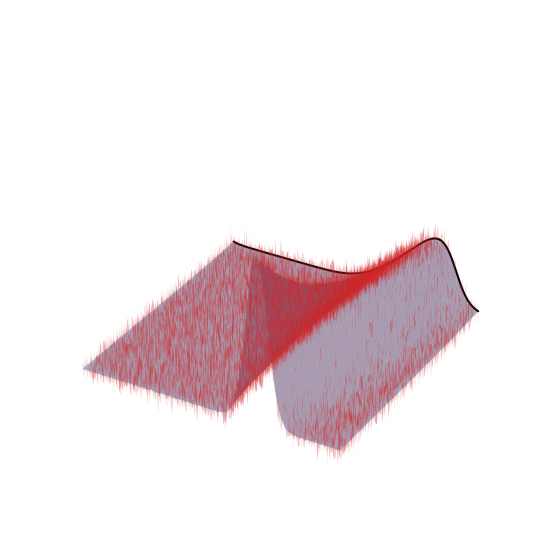

In [3]:
# regenerate HF / LF datasets using the same *absolute* noise levels
X_hf_noisy, t_train, x_grid, _ = generate_burgers_dataset(
    n_traj=cfg.n_hf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=noise_hf_abs,
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)

X_lf_noisy, _, _, _ = generate_burgers_dataset(
    n_traj=cfg.n_lf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=noise_lf_abs,
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)

X_ref, t_ref, x_ref,_ = generate_burgers_dataset(
    n_traj=1,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)

# Choose a single trajectory and a representative time slice
traj_idx = 0

u_hf = X_hf_noisy[traj_idx][:, :, 0]   # (Nx, Nt)
u_lf = X_lf_noisy[traj_idx][:, :, 0]   # (Nx, Nt)
u_ref = X_ref[0][:, :, 0]              # (Nx, Nt)

x = np.squeeze(x_grid)                 # (Nx,)
t = np.squeeze(t_train)                # (Nt,)

Xg, Tg = np.meshgrid(x, t, indexing="ij")  # (Nx, Nt)

fig = plt.figure(figsize=(5, 3.5), dpi=150)
ax = fig.add_subplot(111, projection="3d")

# LF surface (red, more transparent)
ax.plot_surface(
    Xg,
    Tg,
    u_lf,
    color="tab:red",
    alpha=0.25,
    linewidth=0,
    antialiased=True,
    shade=False,
)

# HF surface (blue, less transparent)
ax.plot_surface(
    Xg,
    Tg,
    u_hf,
    color="tab:blue",
    alpha=0.45,
    linewidth=0,
    antialiased=True,
    shade=False,
)

# Reference as a thin black “ridge” at final time
k_ref = -1
ax.plot(
    x,
    np.full_like(x, t[k_ref]),
    u_ref[:, k_ref],
    color="black",
    linewidth=1.0,
)

# Compact panel: no ticks, no axes, no titles
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.set_axis_off()
ax.grid(False)

plt.tight_layout(pad=0.05)
plt.show()


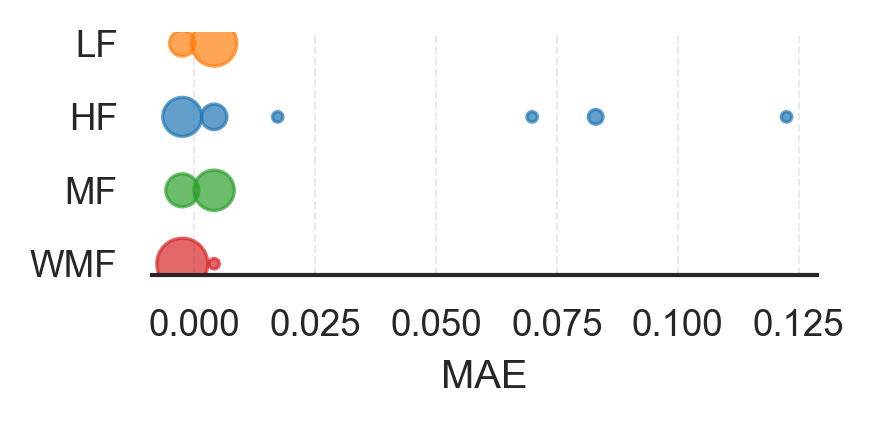

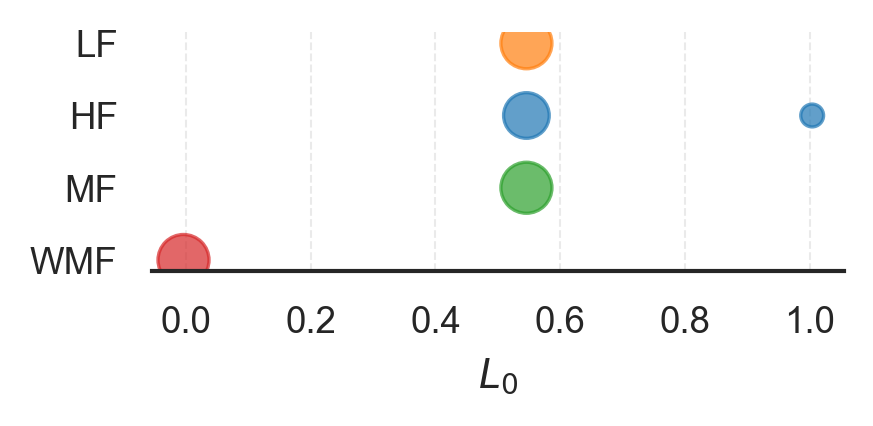

In [4]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    # title=f"Burgers Part 1: MAE ({cfg.n_runs} runs)",
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    # title=f"Burgers Part 1: $L_0$ ({cfg.n_runs} runs)",
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

